# Proyek Machine Learning - Analisis Performa Akademik Siswa
Notebook ini dibuat untuk memprediksi kelulusan siswa berdasarkan fitur demografis dan sosial, serta memahami fitur mana yang paling berpengaruh terhadap performa akademik siswa. Dataset diambil dari Kaggle: [Students Performance](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

## Import Library

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, confusion_matrix
from math import sqrt

## Load Data


Pada bagian ini, dataset StudentsPerformance.csv dibaca menggunakan library pandas, lalu lima baris pertama dari dataset ditampilkan menggunakan df.head(). Ini bertujuan untuk mendapatkan gambaran awal tentang struktur dan isi data sebelum dilakukan analisis lebih lanjut.

In [17]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Data Understanding


Pada tahap ini, dilakukan pemahaman awal terhadap data, termasuk melihat tipe data, deskripsi statistik, jumlah missing values, dan duplikat data. Langkah ini penting untuk mengetahui kualitas dan karakteristik data sebelum dilakukan eksplorasi dan pemodelan lebih lanjut.


### Melihat dimensi dataset


In [18]:
print(f"Jumlah baris dan kolom: {df.shape}")

Jumlah baris dan kolom: (1000, 8)


### Melihat tipe data dan non-null count


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Menampilkan statistik deskriptif untuk kolom numerik


In [20]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Menampilkan jumlah nilai unik di setiap kolom


In [21]:
print("\nJumlah nilai unik di setiap kolom:")
print(df.nunique())


Jumlah nilai unik di setiap kolom:
gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64


### Mengecek missing value

In [22]:
print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())


Jumlah missing value di setiap kolom:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Mengecek duplikat

In [23]:
print("\nJumlah duplikat:")
print(df.duplicated().sum())


Jumlah duplikat:
0


## Exploratory Data Analysis (EDA)



### Visualisasi Distribusi Fitur Numerikal

#### Distribusi Fitur Numerik
Langkah awal EDA dilakukan dengan melihat distribusi dari fitur numerik, yaitu skor matematika, membaca, dan menulis. Tujuannya adalah untuk memahami sebaran nilai dan potensi skewness yang mungkin mempengaruhi model.

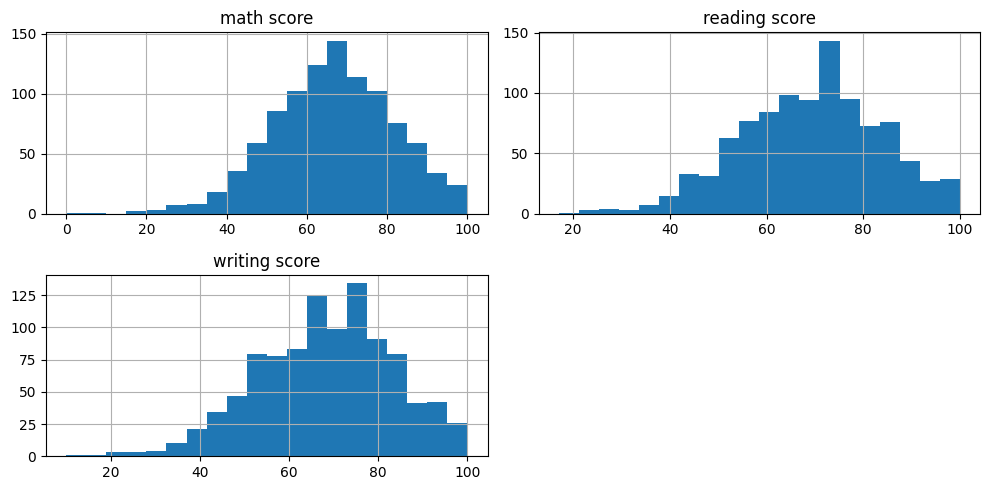

In [24]:
numeric_cols = ['math score', 'reading score', 'writing score']
df[numeric_cols].hist(bins=20, figsize=(10, 5))
plt.tight_layout()
plt.show()

#### Insight dari Visualisasi Numerik
Distribusi nilai matematika, membaca, dan menulis cenderung normal dengan sedikit skew. Hal ini menunjukkan bahwa sebagian besar siswa berada di nilai tengah, dan hanya sedikit siswa yang memiliki nilai sangat rendah atau sangat tinggi.


#### 📊 Distribusi Nilai Ujian Siswa

Grafik di atas menunjukkan distribusi dari tiga jenis nilai ujian yang dimiliki oleh siswa, yaitu:

1. **Math Score (Nilai Matematika)**  
   Distribusi nilai matematika terlihat agak menyebar ke kiri (left-skewed), dengan sebagian besar siswa memperoleh nilai antara **50 hingga 80**. Namun masih terdapat siswa yang mendapat nilai sangat rendah di bawah 30, menandakan adanya kelompok siswa yang kesulitan dalam matematika.

2. **Reading Score (Nilai Membaca)**  
   Distribusi nilai membaca cenderung mendekati normal, dengan puncak sekitar nilai **70–80**. Ini menunjukkan bahwa mayoritas siswa memiliki kemampuan membaca yang cukup baik. Nilai ekstrem rendah jarang ditemukan pada mata pelajaran ini.

3. **Writing Score (Nilai Menulis)**  
   Distribusi nilai menulis juga mirip dengan membaca, tapi sedikit lebih datar. Sebagian besar siswa mendapatkan nilai di atas **60**, dan terlihat ada dua puncak nilai (**bimodal**), yang bisa menunjukkan adanya dua kelompok performa siswa dalam menulis.

---

### 🔍 Insight Utama:
- Rata-rata siswa memiliki nilai membaca dan menulis yang lebih baik dibanding matematika.
- Sebagian siswa mengalami kesulitan besar dalam matematika, yang bisa menjadi fokus intervensi.
- Distribusi nilai ini dapat membantu dalam mengelompokkan siswa berdasarkan kekuatan dan kelemahan mereka dalam masing-masing mata pelajaran.

### Visualisasi Fitur Kategorikal

#### Analisis Fitur Kategorikal
Selain fitur numerik, penting untuk mengeksplorasi fitur kategorikal seperti gender, etnis, tingkat pendidikan orang tua, dan status makan siang. Visualisasi ini membantu mengidentifikasi distribusi dan proporsi kategori, serta hubungannya terhadap skor siswa.


<ipython-input-25-ad862cca7d59>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


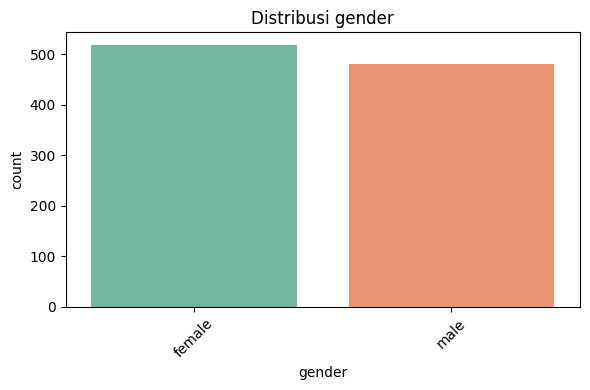

<ipython-input-25-ad862cca7d59>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


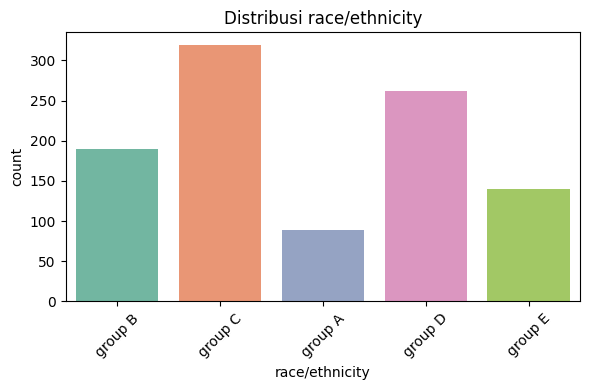

<ipython-input-25-ad862cca7d59>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


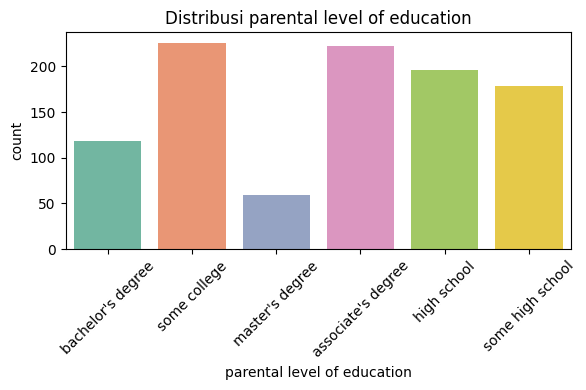

<ipython-input-25-ad862cca7d59>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


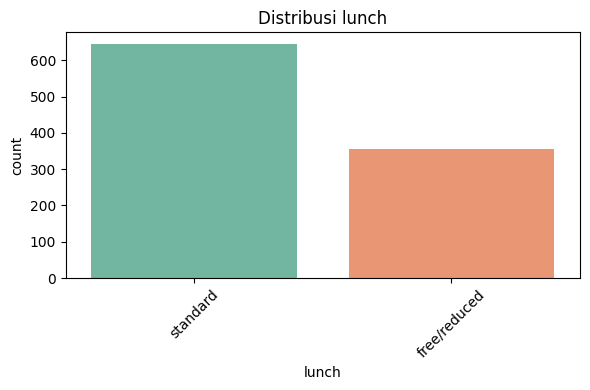

<ipython-input-25-ad862cca7d59>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


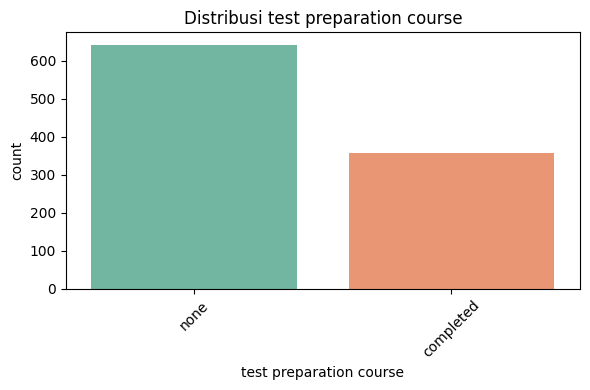

In [25]:
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Insight dari Fitur Kategorikal
Dari distribusi fitur kategorikal, terlihat bahwa:
- **Gender** cukup seimbang, namun perempuan sedikit lebih banyak.
- **Etnis grup** B adalah yang paling dominan.
- Mayoritas siswa tidak mengikuti kursus persiapan ujian.
- Sebagian besar siswa mendapat makan siang standar.


### Multivariate Analysis

Analisis multivariat digunakan untuk mengevaluasi hubungan antara dua atau lebih fitur. Salah satu pendekatan yang digunakan adalah korelasi antar skor ujian, serta visualisasi hubungan antara fitur kategorikal dengan skor tertentu menggunakan boxplot.


#### Korelasi Antar Skor Ujian

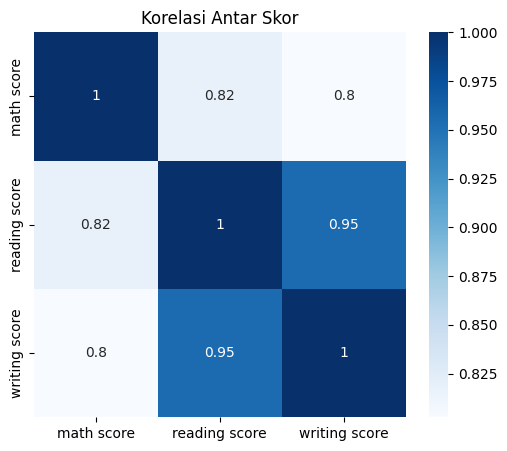

In [26]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='Blues')
plt.title('Korelasi Antar Skor')
plt.show()

#### Hubungan Fitur Kategorikal dengan Skor Ujian

<ipython-input-27-e2f329fac840>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='math score', palette='Set3')


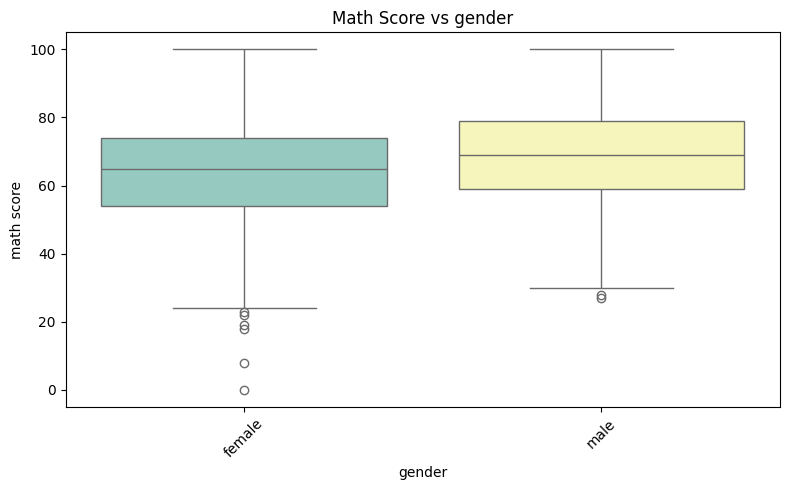

<ipython-input-27-e2f329fac840>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='math score', palette='Set3')


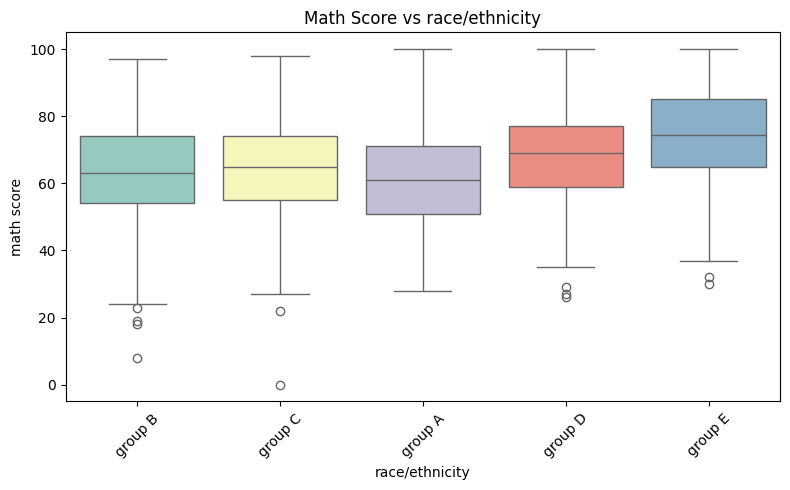

<ipython-input-27-e2f329fac840>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='math score', palette='Set3')


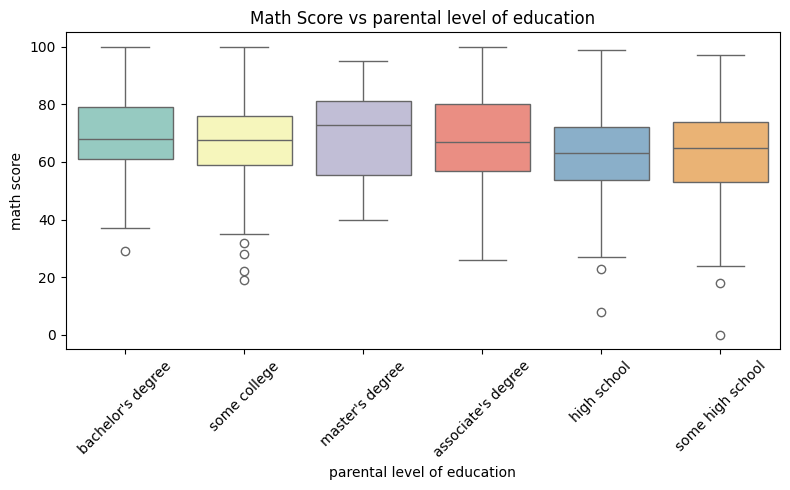

<ipython-input-27-e2f329fac840>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='math score', palette='Set3')


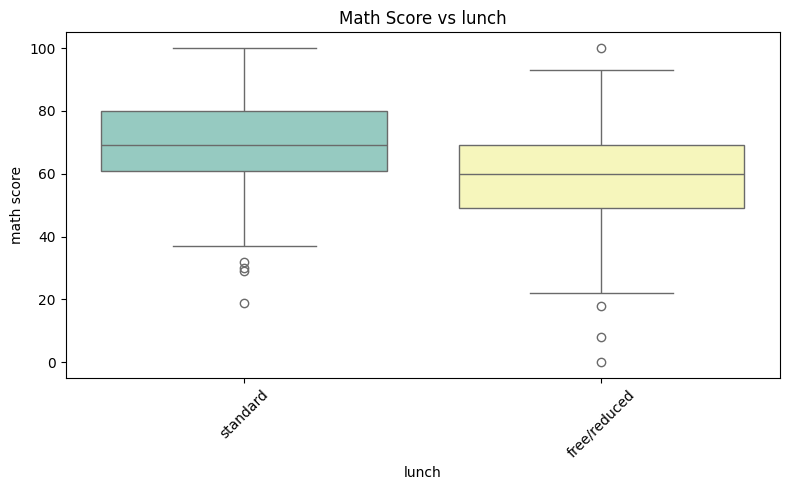

<ipython-input-27-e2f329fac840>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='math score', palette='Set3')


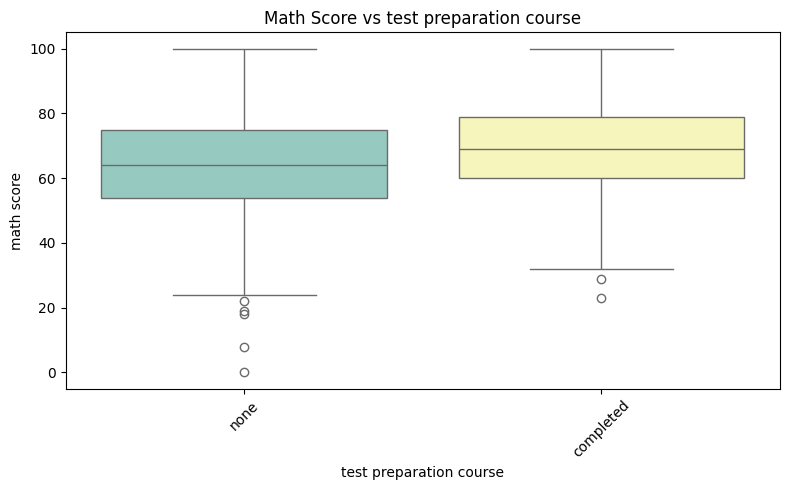

In [27]:
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col, y='math score', palette='Set3')
    plt.title(f'Math Score vs {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Insight dari Multivariate Analysis
Dari heatmap korelasi:
- Terdapat korelasi positif kuat antara nilai membaca dan menulis.
- Nilai matematika memiliki korelasi yang lebih lemah terhadap dua lainnya, namun tetap positif.

Boxplot menunjukkan bahwa:
- Siswa dengan makan siang standar memiliki skor matematika lebih tinggi dibandingkan yang mendapat subsidi.
- Kursus persiapan ujian memberikan dampak positif terhadap skor matematika.


## Data Preparation
- Menambahkan kolom **target kelulusan** untuk setiap mata pelajaran (`math_pass`, `reading_pass`, `writing_pass`), di mana siswa dianggap **lulus jika nilainya ≥ 65**.
- Melakukan **label encoding** pada fitur kategorikal: `gender`, `race/ethnicity`, `parental level of education`, `lunch`, dan `test preparation course`.
- Menentukan fitur (`X`) dengan menghapus kolom nilai asli (`math score`, `reading score`, `writing score`) dan kolom target kelulusan dari dataset.

In [28]:
# Buat kolom pass/fail berdasarkan threshold 65
df['math_pass'] = (df['math score'] >= 65).astype(int)
df['reading_pass'] = (df['reading score'] >= 65).astype(int)
df['writing_pass'] = (df['writing score'] >= 65).astype(int)

# Encode fitur kategorikal
label_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Fitur umum
X = df.drop(columns=[
    'math score', 'reading score', 'writing score',
    'math_pass', 'reading_pass', 'writing_pass'
])

### Data Splitting

- Menentukan **target klasifikasi** untuk kelulusan:
  - `math_pass`: 1 jika lulus matematika (nilai ≥ 65), 0 jika tidak.
  - `reading_pass`: 1 jika lulus membaca.
  - `writing_pass`: 1 jika lulus menulis.

- Menentukan **target regresi** untuk memprediksi nilai aktual:
  - `math score`, `reading score`, dan `writing score`.

- Melakukan **pembagian data (train-test split)** secara terpisah untuk:
  - **Klasifikasi** kelulusan pada masing-masing mata pelajaran.
  - **Regresi** prediksi nilai untuk masing-masing mata pelajaran.

> Pembagian data dilakukan dengan rasio 80:20 dan `random_state=42` untuk memastikan replikasi hasil.

In [29]:
# Target klasifikasi
y_math_pass = df['math_pass']
y_reading_pass = df['reading_pass']
y_writing_pass = df['writing_pass']

# Target regresi
y_math_score = df['math score']
y_reading_score = df['reading score']
y_writing_score = df['writing score']

# Split data
X_train_math, X_test_math, y_train_math, y_test_math = train_test_split(X, y_math_pass, test_size=0.2, random_state=42)
X_train_reading, X_test_reading, y_train_reading, y_test_reading = train_test_split(X, y_reading_pass, test_size=0.2, random_state=42)
X_train_writing, X_test_writing, y_train_writing, y_test_writing = train_test_split(X, y_writing_pass, test_size=0.2, random_state=42)

X_train_math_reg, X_test_math_reg, y_train_math_reg, y_test_math_reg = train_test_split(X, y_math_score, test_size=0.2, random_state=42)
X_train_reading_reg, X_test_reading_reg, y_train_reading_reg, y_test_reading_reg = train_test_split(X, y_reading_score, test_size=0.2, random_state=42)
X_train_writing_reg, X_test_writing_reg, y_train_writing_reg, y_test_writing_reg = train_test_split(X, y_writing_score, test_size=0.2, random_state=42)

## Modeling


### Penjelasan Lengkap Modeling


### Model Klasifikasi: Logistic Regression

Kami menggunakan **Logistic Regression** untuk memprediksi kelulusan siswa pada tiga mata pelajaran: matematika, membaca, dan menulis.

- **Tujuan**: Mengklasifikasikan apakah seorang siswa **lulus (nilai ≥ 65)** atau tidak.
- Model ini memodelkan probabilitas keanggotaan kelas (pass/fail) berdasarkan fitur input.
- Parameter:
  - `max_iter=1000`: Jumlah iterasi maksimum untuk konvergensi.
  - Default solver (`lbfgs`) digunakan.

Model dilatih dan diuji secara terpisah untuk setiap mata pelajaran:
- `clf_math` untuk matematika
- `clf_reading` untuk membaca
- `clf_writing` untuk menulis

Evaluasi dilakukan menggunakan metrik klasifikasi seperti **Accuracy**, **Precision**, **Recall**, dan **F1 Score**, serta visualisasi **Confusion Matrix**.

In [30]:
# Logistic Regression: math pass
clf_math = LogisticRegression(max_iter=1000)
clf_math.fit(X_train_math, y_train_math)
y_pred_math = clf_math.predict(X_test_math)

# Logistic Regression: reading pass
clf_reading = LogisticRegression(max_iter=1000)
clf_reading.fit(X_train_reading, y_train_reading)
y_pred_reading = clf_reading.predict(X_test_reading)

# Logistic Regression: writing pass
clf_writing = LogisticRegression(max_iter=1000)
clf_writing.fit(X_train_writing, y_train_writing)
y_pred_writing = clf_writing.predict(X_test_writing)

### Model Regresi: Linear Regression

Kami menggunakan **Linear Regression** untuk memprediksi nilai aktual siswa pada tiga mata pelajaran.

- **Tujuan**: Memodelkan hubungan linier antara fitur input dan nilai skor.
- Model ini berusaha meminimalkan selisih antara nilai sebenarnya dan nilai prediksi.
- Evaluasi menggunakan **Root Mean Squared Error (RMSE)** serta visualisasi **Predicted vs Actual Plot**.

Model dilatih dan diuji untuk setiap target skor:
- `reg_math` memprediksi nilai matematika
- `reg_reading` memprediksi nilai membaca
- `reg_writing` memprediksi nilai menulis

> Semakin kecil nilai RMSE, semakin akurat prediksi model terhadap nilai siswa.

In [31]:
# Linear Regression: math score
reg_math = LinearRegression()
reg_math.fit(X_train_math_reg, y_train_math_reg)
y_pred_math_reg = reg_math.predict(X_test_math_reg)

# Linear Regression: reading score
reg_reading = LinearRegression()
reg_reading.fit(X_train_reading_reg, y_train_reading_reg)
y_pred_reading_reg = reg_reading.predict(X_test_reading_reg)

# Linear Regression: writing score
reg_writing = LinearRegression()
reg_writing.fit(X_train_writing_reg, y_train_writing_reg)
y_pred_writing_reg = reg_writing.predict(X_test_writing_reg)

## Evaluation


### 📊 Metrik Evaluasi

- **Accuracy**: Digunakan untuk model klasifikasi. Mengukur seberapa banyak prediksi yang sesuai dengan label aktual. Nilai ini menunjukkan persentase prediksi yang benar dari seluruh dataset.
  
- **RMSE (Root Mean Square Error)**: Digunakan untuk model regresi. Mengukur rata-rata kesalahan prediksi terhadap nilai aktual. Semakin kecil nilai RMSE, semakin baik model dalam memprediksi nilai yang sebenarnya.

#### Fungsi Evaluasi:
1. **evaluate_classification**:
   - Menghitung metrik klasifikasi seperti **Accuracy**, **Precision**, **Recall**, dan **F1 Score**.
   - Menampilkan **Confusion Matrix** sebagai visualisasi performa model.

2. **evaluate_regression**:
   - Menghitung **RMSE** untuk menilai akurasi prediksi nilai.
   - Menampilkan **scatter plot** yang membandingkan **Actual vs Predicted** nilai, serta garis referensi untuk menunjukkan prediksi yang ideal.

In [32]:
def evaluate_classification(y_true, y_pred, label):
    print(f"\n=== Classification Report: {label} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def evaluate_regression(y_true, y_pred, label):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n=== Regression Report: {label} ===")
    print("RMSE:", rmse)

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.xlabel("Actual Score")
    plt.ylabel("Predicted Score")
    plt.title(f"Regression: {label} - Predicted vs Actual")
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.tight_layout()
    plt.show()

Evaluasi Model Klasifikasi




=== Classification Report: Math Pass ===
Accuracy : 0.655
Precision: 0.648
Recall   : 0.7641509433962265
F1 Score : 0.7012987012987013


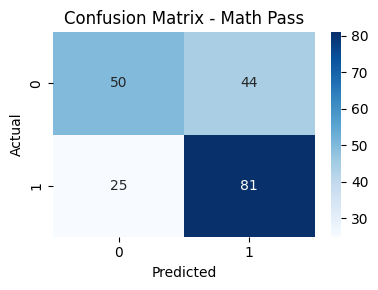


=== Classification Report: Reading Pass ===
Accuracy : 0.62
Precision: 0.6490066225165563
Recall   : 0.8099173553719008
F1 Score : 0.7205882352941176


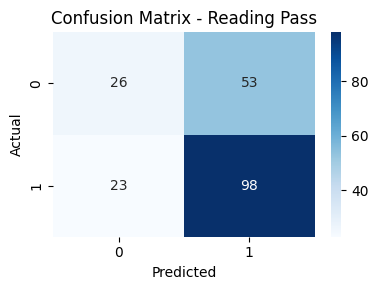


=== Classification Report: Writing Pass ===
Accuracy : 0.67
Precision: 0.6838235294117647
Recall   : 0.8017241379310345
F1 Score : 0.7380952380952381


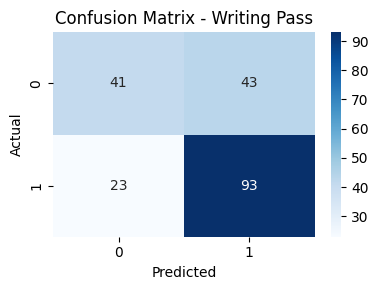

In [33]:
# Logistic Regression: Evaluasi Math Pass
evaluate_classification(y_test_math, y_pred_math, "Math Pass")

# Logistic Regression: Evaluasi Reading Pass
evaluate_classification(y_test_reading, y_pred_reading, "Reading Pass")

# Logistic Regression: Evaluasi Writing Pass
evaluate_classification(y_test_writing, y_pred_writing, "Writing Pass")

Evaluasi Model Regresi


=== Regression Report: Math Score ===
RMSE: 14.243369137656899


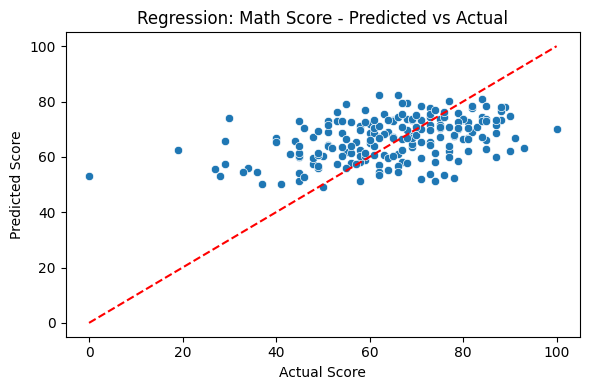


=== Regression Report: Reading Score ===
RMSE: 14.018859672802886


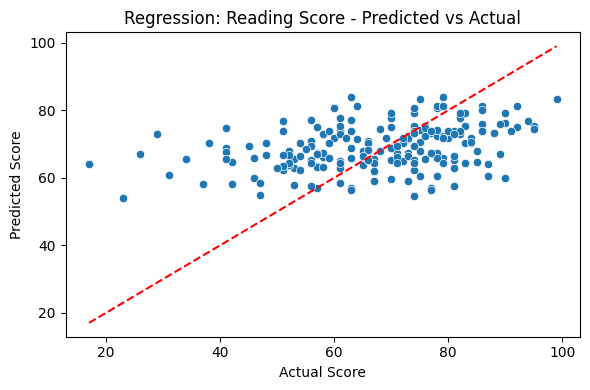


=== Regression Report: Writing Score ===
RMSE: 13.88277303363893


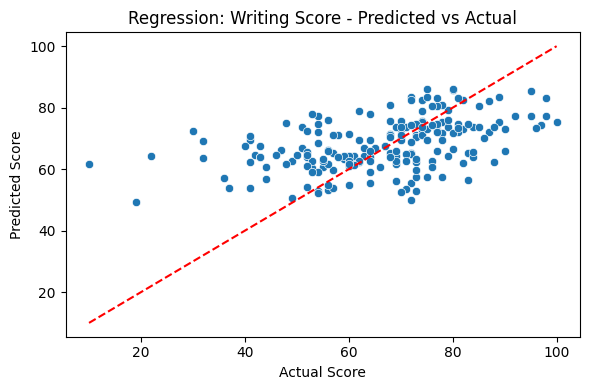

In [34]:
# Linear Regression: Evaluasi Math Score
evaluate_regression(y_test_math_reg, y_pred_math_reg, "Math Score")

# Linear Regression: Evaluasi Reading Score
evaluate_regression(y_test_reading_reg, y_pred_reading_reg, "Reading Score")

# Linear Regression: Evaluasi Writing Score
evaluate_regression(y_test_writing_reg, y_pred_writing_reg, "Writing Score")

### **Interpretasi Hasil dan Keterkaitan dengan Tujuan Bisnis**

#### **Problem Statement 1:**  
Bagaimana cara memprediksi apakah seorang siswa akan lulus mata pelajaran matematika, membaca, dan menulis?

#### **Goal 1:**  
Mengembangkan model klasifikasi untuk memprediksi kelulusan siswa berdasarkan fitur demografis dan sosial.

#### **Hasil & Interpretasi:**  
Model klasifikasi yang digunakan (Logistic Regression) berhasil memberikan hasil sebagai berikut:

- **Math Pass**:
  - **Accuracy:** 65.5%  
  - **Precision:** 64.8%  
  - **Recall:** 76.4%  
  - **F1 Score:** 70.1%  

  Hasil ini menunjukkan bahwa model cukup baik dalam mengidentifikasi siswa yang akan lulus mata pelajaran matematika. Nilai **recall** yang tinggi (76.4%) mengindikasikan bahwa sebagian besar siswa yang benar-benar lulus dapat diprediksi dengan tepat. Namun, **precision** yang sedikit lebih rendah menunjukkan bahwa ada sebagian siswa yang diprediksi lulus namun sebenarnya tidak.

- **Reading Pass**:
  - **Accuracy:** 62%  
  - **Precision:** 64.9%  
  - **Recall:** 80.99%  
  - **F1 Score:** 72.1%  

  Model ini berhasil memprediksi kelulusan dalam mata pelajaran membaca dengan cukup baik, terutama dalam hal **recall**, yang menunjukkan kemampuannya dalam mengidentifikasi siswa yang akan lulus. Namun, ada beberapa kesalahan prediksi dengan **precision** yang lebih rendah.

- **Writing Pass**:
  - **Accuracy:** 67%  
  - **Precision:** 68.4%  
  - **Recall:** 80.17%  
  - **F1 Score:** 73.8%  

  Untuk kelulusan dalam mata pelajaran menulis, model menunjukkan hasil yang baik dengan **recall** yang tinggi (80.17%), mengindikasikan bahwa sebagian besar siswa yang benar-benar lulus berhasil diprediksi.

Secara keseluruhan, model ini dapat dimanfaatkan oleh sekolah untuk mengidentifikasi siswa yang kemungkinan besar akan gagal lebih awal, sehingga dapat diberikan intervensi atau dukungan tambahan.

---

#### **Problem Statement 2:**  
Fitur demografis dan sosial apa yang paling memengaruhi performa akademik siswa?

#### **Goal 2:**  
Mengetahui fitur demografis dan sosial yang paling memengaruhi performa akademik siswa.

#### **Hasil & Interpretasi:**  
Berdasarkan analisis multivariat dan korelasi, ditemukan bahwa:

- Terdapat korelasi yang kuat antara skor membaca dan menulis.
- Fitur **jenis kelamin**, **tipe makan siang**, dan **program persiapan ujian** menunjukkan pengaruh yang jelas terhadap skor akademik, terutama matematika.

Dalam model regresi untuk prediksi nilai matematika, didapatkan hasil **RMSE sebesar 14.24**. Artinya, rata-rata kesalahan prediksi skor matematika adalah sekitar 14 poin.

Selain itu, model regresi untuk prediksi skor membaca dan menulis menghasilkan **RMSE** sebagai berikut:

- **Reading Score RMSE**: 14.02  
- **Writing Score RMSE**: 13.88  

Ini menunjukkan bahwa model regresi memiliki akurasi yang moderat, dan masih ada ruang untuk peningkatan dengan menambahkan fitur atau memperbaiki model.

---

Dengan hasil evaluasi ini, sekolah dapat mengetahui faktor-faktor yang paling berpengaruh terhadap kelulusan dan skor akademik siswa serta mengambil tindakan yang tepat untuk meningkatkan performa siswa.